#### Gradient Descent
- An algorithm designed to minimize a given function.
- In this context, we use gradient descent to minimize the cost function, helping us determine the optimal values for `b` and `w`

So far in this course, you have developed a linear model that predicts $f_{w,b}(x^{(i)})$:
$$f_{w,b}(x^{(i)}) = wx^{(i)} + b \tag{1}$$
In linear regression, you utilize input training data to fit the parameters $w$,$b$ by minimizing a measure of the error between our predictions $f_{w,b}(x^{(i)})$ and the actual data $y^{(i)}$. The measure is called the $cost$, $J(w,b)$. In training you measure the cost over all of our training samples $x^{(i)},y^{(i)}$
$$J(w,b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2\tag{2}$$ 


<br/><br/>
**Gradient Descent** was described as:

$$\begin{align*} \text{repeat}&\text{ until convergence:} \; \lbrace \newline
\;  w &= w -  \alpha \frac{\partial J(w,b)}{\partial w} \tag{3}  \; \newline 
 b &= b -  \alpha \frac{\partial J(w,b)}{\partial b}  \newline \rbrace
\end{align*}$$
where, parameters $w$, $b$ are updated simultaneously.  


The gradient is defined as:
$$
\begin{align}
\frac{\partial J(w,b)}{\partial w}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})x^{(i)} \tag{4}\\
  \frac{\partial J(w,b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)}) \tag{5}\\
\end{align}
$$

Here *simultaniously* means that you calculate the partial derivatives for all the parameters before updating any of the parameters.

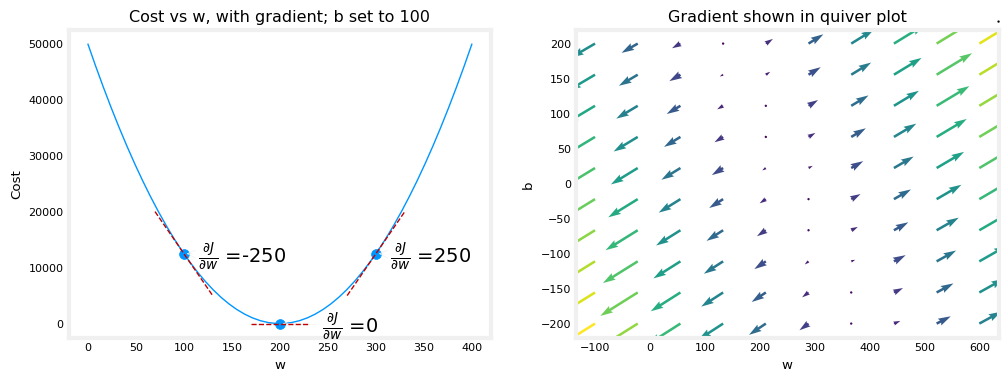

In [2]:
import math, copy
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('util/deeplearning.mplstyle')


x_train = np.array([1.0, 2.0])       #features
y_train = np.array([300.0, 500.0])   #target value



def compute_gradient(x_train: np.array, y_train: np.array, w: float, b: float) -> tuple(float, float):
    m = x_train.shape[0]    # no of training data

    # partial derivative of J with respect to w and b
    dj_dw = 0     
    dj_db = 0

    for x, y in zip(x_train, y_train):
        f_wb = x * w + b     # predicted value
        error = f_wb - y     # diff b/w predicited & target

        dj_dw += error * x
        dj_db += error

    dj_dw /= m
    dj_db /= m

    return dj_dw, dj_db

        
# let's plot the variation of cost function vs the weight 
# also mark the gradient and see how it behaves
from util.univariate import plt_gradients
plt_gradients(x_train, y_train, compute_gradient)
plt.show()

##### Intitution of Gradient (partial derivative)

- when the point is on left side, the derivative is -ive, indicating an increase in the value of w (move to the right)
- when the point is on right side, the derivative is +ive, indicating a decrease in the value of w (move to the left)

From this, we can conclude that the derivative determines the direction in which the cost function converges.

Once the point reaches the minimal point, then the derivative is 0 (slope of horizontal line is zero).
After that, update of `w` will not happen
$$ w = w - \alpha * 0 $$
$$ w = w $$

#### Compute Gradient Descent (with one feature - x)

$$\begin{align*} \text{repeat}&\text{ until convergence:} \; \lbrace \newline
\;  w &= w -  \alpha \frac{\partial J(w,b)}{\partial w} \tag{3}  \; \newline 
 b &= b -  \alpha \frac{\partial J(w,b)}{\partial b}  \newline \rbrace
\end{align*}$$
where, parameters $w$, $b$ are updated simultaneously. 


STEPS
1. `compute_gradient`
2. `update the parameters`
3. `repeat`

In [3]:
from util.common import compute_cost

def compute_gradient_descent(x_train: np.array, y_train: np.array, alpha :float, w_in :float, b_in :float, iterations :int) -> tuple:
    j_wb = []          # record cost function for each w & b
    parameters = []    # record parameters (w, b) in each iteration

    w = w_in
    b = b_in

    for i in range(iterations):
        # compute the gradient
        dj_dw, dj_db = compute_gradient(x_train, y_train, w, b)

        # update the parameters
        w -= alpha * dj_dw
        b -= alpha * dj_db

        # for graphing purpose only (record cost function and parameters)
        parameters.append((w, b))
        j_wb.append(compute_cost(x_train, y_train, w, b))

        # for every n iterations, let's print the values
        # if (i % 1000 == 0):
        print(f"{i:4} || dj_dw: {dj_dw:0.3E}| dj_db: {dj_db:0.3E}| J(w, b): {j_wb[-1]:0.3E}| w: {w}, b: {b}")

    return w, b, j_wb, parameters






# let's initialize parameters and run the gradient descent algorithm
w_in = 100
b_in = 1000
iterations = 10000
alpha = 1.0E-2

w, b, j_wb, parameters = compute_gradient_descent(x_train, y_train, alpha, w_in, b_in, iterations)
print(f"\n(w,b) found by gradient descent: ({w:8.3f}, {b:8.3f})")

#### Cost Vs Iterations
Let's visualize the minimization of the cost function over each iteration using a plot. This provides insight into the speed of convergence and the number of iterations required for significant progress.

##### Observations from the plot (below)
- The cost value changed significantly during the first 1500 iterations.
- After 2000 iterations, the cost function stabilized.
- From this, we can conclude that a total of 2000 iterations is sufficient for the cost function to reach its lowest point.


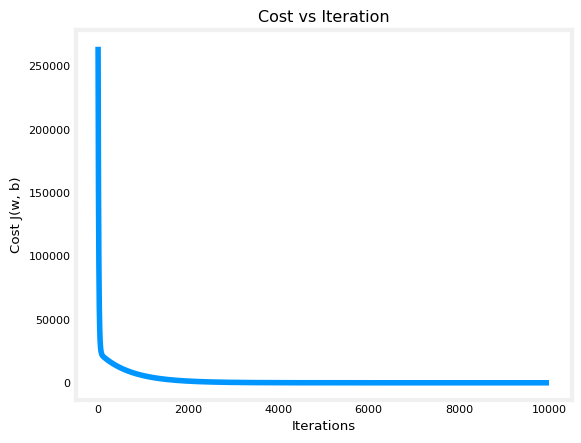

In [3]:
plt.plot([i for i in range(10000)], j_wb, label='cost vs iterations')
plt.title("Cost vs Iteration")
plt.ylabel('Cost J(w, b)')
plt.xlabel('Iterations')
plt.show()

#### Cost Function's Path along the Contour Plot

Let's plot the variation of the cost function for all the w and b values generated during each iteration on the contour plot (parameters versus cost function).

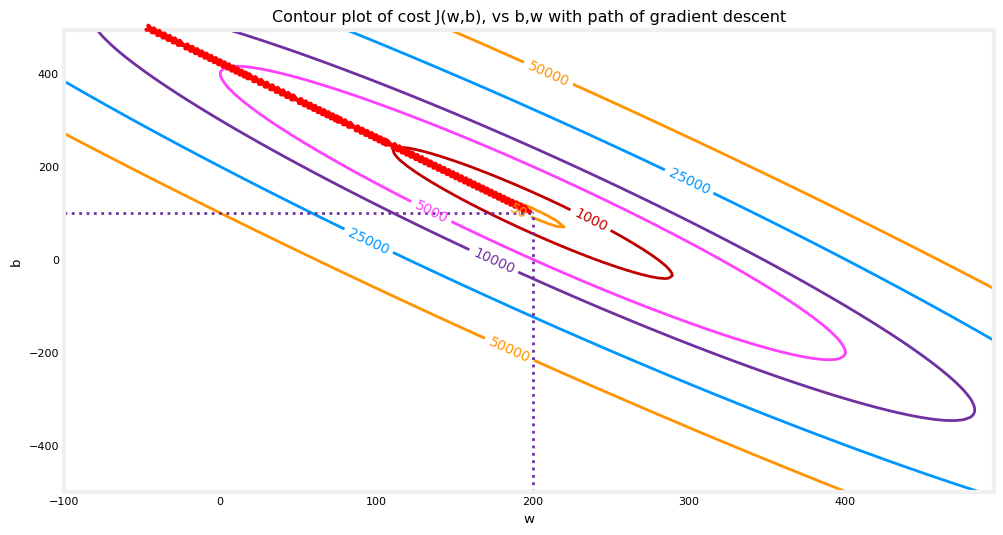

In [4]:
from util.univariate import plt_contour_wgrad

fig, axes = plt.subplots(1, 1, figsize=(12, 6))
plt_contour_wgrad(x_train, y_train, parameters, axes)

Based on the plot, the cost function steadily progressed toward the goal in a steep manner. Let's zoom in to observe how the cost function behaves as it approaches its minimum value.

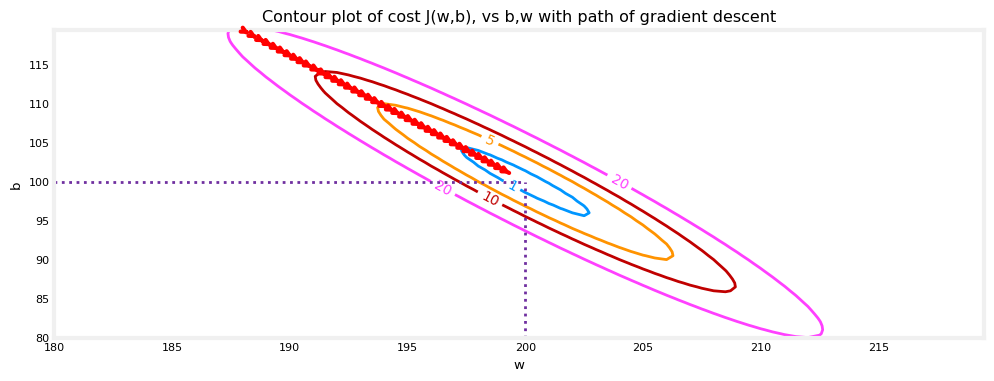

In [5]:
fig, axes = plt.subplots(1,1, figsize=(12, 4))
plt_contour_wgrad(
    x_train, y_train, 
    parameters, 
    axes, 
    w_range=[180, 220, 0.5], 
    b_range=[80, 120, 0.5],
    contours=[1,5,10,20],
    resolution=0.5
)

#### Ananlysis of Learning Rate ($ \alpha $)
- learning rate $ \alpha $ determines how faster the gradient converges to minimal point
- higher the alpha, faster the gradient descents to solution
- too larger the alpha, gradient descent will diverge

Let's plot on what happens, if the $ \alpha $ value is too high

In [4]:
# let's initialize parameters and run the gradient descent algorithm
w_in = 0
b_in = 0
iterations = 10
large_alpha = 8.0E-1

# run gradient descent
w, b, j_wb, parameters = compute_gradient_descent(x_train, y_train, large_alpha, w_in, b_in, iterations)

   0 || dj_dw: -6.500E+02| dj_db: -4.000E+02| J(w, b): 2.578E+05| w: 520.0, b: 320.0
   1 || dj_dw: 1.130E+03| dj_db: 7.000E+02| J(w, b): 7.820E+05| w: -384.0, b: -240.0
   2 || dj_dw: -1.970E+03| dj_db: -1.216E+03| J(w, b): 2.372E+06| w: 1192.0, b: 732.8000000000001
   3 || dj_dw: 3.429E+03| dj_db: 2.121E+03| J(w, b): 7.195E+06| w: -1551.3600000000006, b: -963.8400000000003
   4 || dj_dw: -5.974E+03| dj_db: -3.691E+03| J(w, b): 2.182E+07| w: 3227.9680000000008, b: 1988.864000000001
   5 || dj_dw: 1.040E+04| dj_db: 6.431E+03| J(w, b): 6.620E+07| w: -5094.604800000003, b: -3155.7888000000016
   6 || dj_dw: -1.812E+04| dj_db: -1.120E+04| J(w, b): 2.008E+08| w: 9401.551360000005, b: 5802.368000000004
   7 || dj_dw: 3.156E+04| dj_db: 1.950E+04| J(w, b): 6.091E+08| w: -15844.392960000008, b: -9801.388032000004
   8 || dj_dw: -5.496E+04| dj_db: -3.397E+04| J(w, b): 1.848E+09| w: 28126.058598400017, b: 17372.993945600007
   9 || dj_dw: 9.572E+04| dj_db: 5.916E+04| J(w, b): 5.604E+09| w: -4845

What we observe from the output, 
- `w` and `b` value bounce back b/w positive and negative values and the absolute value is increasing
- cost function `J(w, b)` also increasing instead of decreasing
- gradient also bouncing b/w positive and negative values

These are the clear evidence that the learning rate is set too high. <br/>
Let's plot and see how it behavious graphically

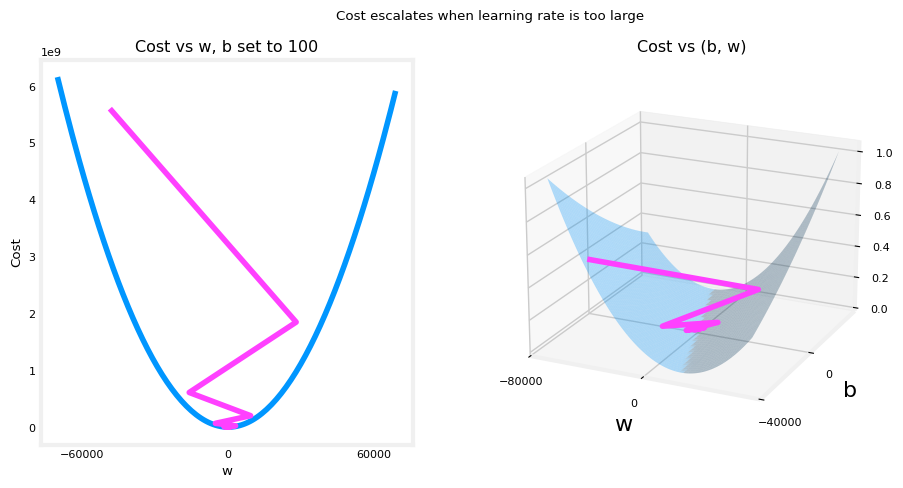

In [5]:
from util.univariate import plt_divergence

plt_divergence(parameters, j_wb, x_train, y_train)
plt.show()